<a href="https://colab.research.google.com/github/anitaharo24-code/ds-week-2/blob/master/M2_T1_Pr%C3%A1ctica_de_aprendizaje_no_supervisado_Jer%C3%A1rquico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aprendizaje no supervisado Aglomerativo Jerárquico


Roberto Sánchez, rg.sanchez.a@gmail.com

---

El agrupamiento es un método de aprendizaje no supervisado que nos permite agrupar un conjunto de objetos basados en características similares. En general, puede ayudar a encontrar estructuras significativas entre los datos, agrupar datos similares y descubrir patrones subyacentes.

Las técnicas jerárquicas son realmente útiles cuando puede afirmar que existe una tendencia natural a construir una jerarquía en su dominio. Por ejemplo, en el set de datos de flores, es posible obtener una estructura de los tres tipos de flores presentes en el set de datos

##Set de datos a usar:


In [ ]:
# Importar librerias
from sklearn import datasets
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
import seaborn as sns; sns.set(style="ticks", color_codes=True)


In [ ]:
# Cargar set de datos:
iris = sns.load_dataset("iris")
iris.head(5)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
# separamos caracteristicas y la variable objetivo
caracteristicas = ["sepal_length", "sepal_width", "petal_length", "petal_width"]
X = iris[caracteristicas]
y = iris["species"]
# g = sns.pairplot(X, kind="reg", vars=caracteristicas)

# Jerárquico Aglomerativo

Recuerde que la agrupación aglomerativa es el acto de formar grupos de abajo hacia arriba.

Comenzamos con observaciones individuales como grupos, luego las asignamos iterativamente al grupo más cercano.

Finalmente, terminamos con una serie de grupos (que deben especificarse de antemano).

Sigamos con enlaces tipo "complete" para definir cómo fusionar los grupos. Es posible decirle al algoritmo que defina 3 grandes grupos (n_clusters), sin embargo esto no es necesario si el investigador lo considera así.

La distancia usada por defecto es euclidiana, existe la posibilidad de cambiarla, los demás valores pueden quedar por defecto.

## Qué ocurre si se cambio de tipo de enlace?


In [ ]:
from sklearn.cluster import AgglomerativeClustering
clustering = AgglomerativeClustering(linkage="complete", n_clusters=3)
clustering.fit(X)

AgglomerativeClustering(affinity='euclidean', compute_full_tree='auto',
                        connectivity=None, distance_threshold=None,
                        linkage='complete', memory=None, n_clusters=3,
                        pooling_func='deprecated')

Observemos un ejemplos de los agrupamientos

In [ ]:
grupos = clustering.labels_
grupos

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 2, 0, 2, 0, 2, 0, 2, 2, 2, 2, 0, 2, 0,
       2, 2, 0, 2, 0, 2, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 0, 2, 0, 0, 0,
       2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 2, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

# Análisis de las agrupaciones

In [ ]:
# Añadir la etiqueta grupo en el set de datos original

iris["grupos"] = ["G." + str(x) for x in grupos]
iris["grupos_id"] = grupos
iris

,sepal_length,sepal_width,petal_length,petal_width,species,grupos,grupos_id
0,5.1,3.5,1.4,0.2,setosa,G.1,1
1,4.9,3.0,1.4,0.2,setosa,G.1,1
2,4.7,3.2,1.3,0.2,setosa,G.1,1
3,4.6,3.1,1.5,0.2,setosa,G.1,1
4,5.0,3.6,1.4,0.2,setosa,G.1,1
5,5.4,3.9,1.7,0.4,setosa,G.1,1
6,4.6,3.4,1.4,0.3,setosa,G.1,1
7,5.0,3.4,1.5,0.2,setosa,G.1,1
8,4.4,2.9,1.4,0.2,setosa,G.1,1
9,4.9,3.1,1.5,0.1,setosa,G.1,1


# Muestras con sus respectivas etiquetas

Se observa los datos originales:

In [ ]:
#sns.pairplot(iris[["sepal_length", "sepal_width"] + ["species"]], hue="species",height=2)
#sns.pairplot(iris[["sepal_length", "sepal_width"] + ["grupos"]], hue="grupos",height=2)

In [ ]:
#sns.pairplot(iris[["sepal_length", "sepal_width", "grupos_id"] + ["species"]], hue="species",height=2)

#Dendrograms

Los dendrogramas son gráficos jerárquicos de grupos donde la longitud de las barras representa la distancia al siguiente centro de grupo.
.

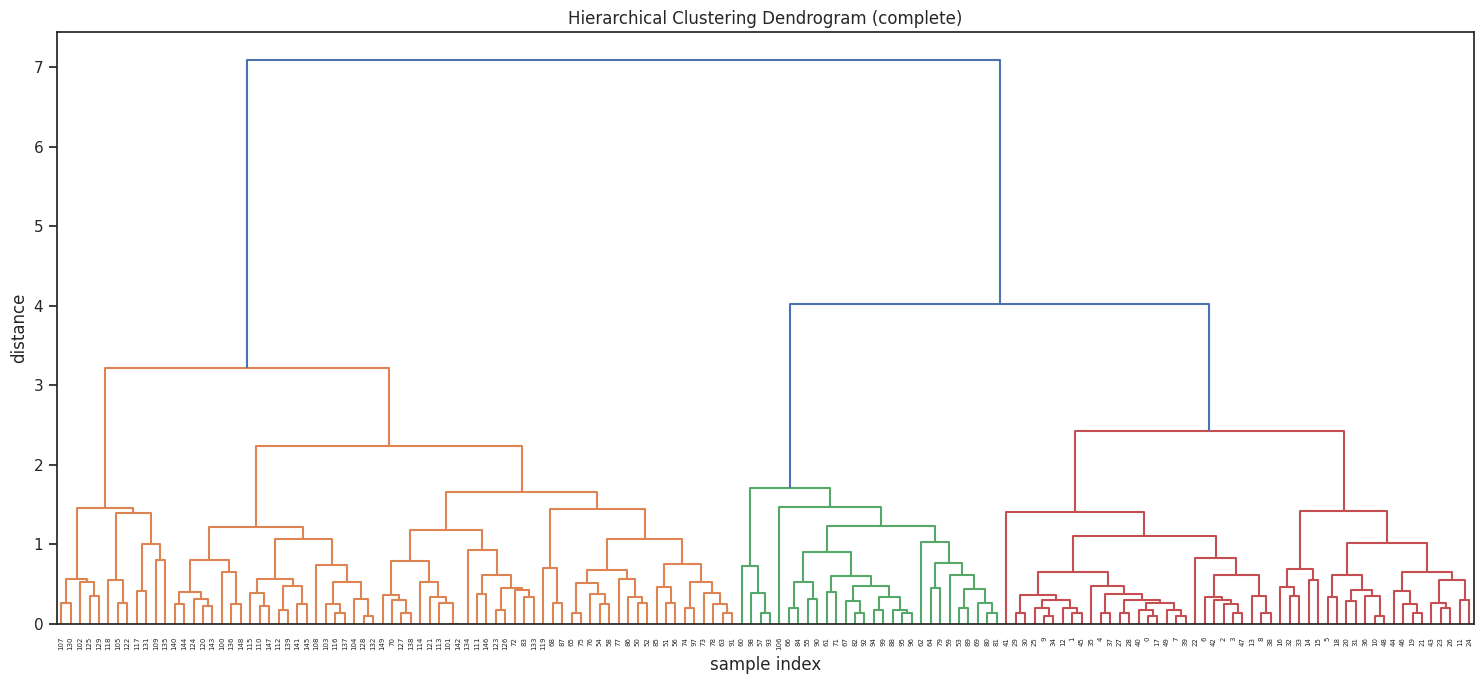

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage

linkage_matrix = linkage(X, 'complete')
figure = plt.figure(figsize=(15, 7))
dendrogram(
    linkage_matrix,
    color_threshold=3.5,
)
plt.title('Hierarchical Clustering Dendrogram (complete)')
plt.xlabel('sample index')
plt.ylabel('distance')
plt.tight_layout()
plt.show()